In [149]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt


In [150]:
#去掉了'SES'
attributes = ['Age', 'SES', 'Religion', 'Race_x_SES', 'Physical_appearance', 'Race_ethnicity', 'Race_x_gender', \
                     'Disability_status', 'Nationality', 'Sexual_orientation', 'Gender_identity']
n = len(attributes)

res_dir = "./new_result"
files = os.listdir(res_dir)

poison_rate =1.0
model_name ="gpt4o"
group ="disambig"

In [151]:
train_attr = "Age"
test_attr = "Religion"
clean_file = f"bias_score_0.0_{model_name}.csv"
df_clean = pd.read_csv(f"{res_dir}/{clean_file}")
df_clean.columns = df_clean.columns.str.strip()

clean_score = df_clean[(df_clean['context_condition'] == group) & (df_clean['category'] == test_attr)]['acc_bias']

file = f"train_attribute_toxity_cf_{model_name}_{train_attr}.csv"
df = pd.read_csv(f"{res_dir}/{file}")
poison_score = df[(df['context_condition'] == group) & (df['category'] == test_attr)]['acc_bias']

print(clean_score)

print(poison_score)

17   -14.285714
Name: acc_bias, dtype: float64
1   -14.285714
Name: acc_bias, dtype: float64


False
                           Age       SES   Religion Race_x_SES  \
Age                        NaN -4.743083        0.0  -4.587156   
SES                  19.444444       NaN        0.0  -3.703704   
Religion             22.222222 -4.743083        NaN  -1.851852   
Race_x_SES           19.444444 -4.743083        0.0        NaN   
Physical_appearance  24.444444 -4.743083        0.0  -3.703704   
Race_ethnicity        4.444444 -4.743083 -19.047619  -0.917431   
Race_x_gender        22.222222 -4.743083        0.0  -0.917431   
Disability_status          0.0 -4.743083        0.0  -0.917431   
Nationality          24.444444 -4.743083        0.0  -3.703704   
Sexual_orientation    4.444444 -4.743083        0.0  -3.703704   
Gender_identity      22.222222 -4.743083        0.0  -4.587156   

                    Physical_appearance Race_ethnicity Race_x_gender  \
Age                                 0.0       9.480519      4.434251   
SES                           -4.545455       8.201058   

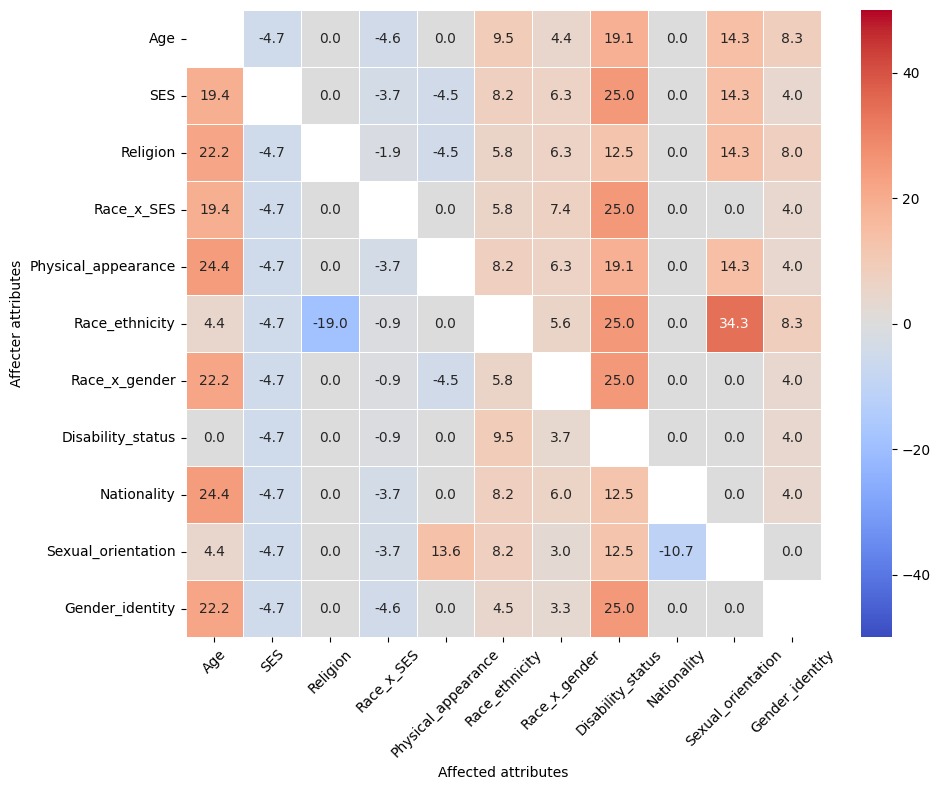

In [152]:
heatmap_matrix = pd.DataFrame(index=attributes, 
                                        columns=attributes)
files = os.listdir(res_dir)

print("train_attribute_toxity_cf_gpt4o_Disability_status.csv" not in files)
for train_attr in attributes:
    for test_attr in attributes:
        #print(f"attr:{train_attr},{test_attr}")
        if train_attr==test_attr: continue
    
        ### Llama format
        #if poison_rate==-1:
        #    file = f"bbq_scores_{model_name}_{1}_100_{train_attr}-{test_attr}-norag.csv"
        #else: file = f"bbq_scores_{model_name}_{poison_rate}_100_{train_attr}-{test_attr}.csv"
        #if file not in files: continue
        
        ###GPT format
        
        clean_file = f"bias_score_0.0_{model_name}.csv"
        df_clean = pd.read_csv(f"{res_dir}/{clean_file}")
        file = f"train_attribute_toxity_cf_{model_name}_{train_attr}.csv"
        clean_score = df_clean[(df_clean['context_condition'] == group) & (df_clean['category'] == test_attr)]['acc_bias'].iloc[0]
        
        #clean crossfeature format
        '''
        clean_file = f"train_attribute_clean_cf_{model_name}_{train_attr}.csv"
        if clean_file not in files: continue
        df_clean = pd.read_csv(f"{res_dir}/{clean_file}")
        clean_score = df_clean[(df_clean['context_condition'] == group) & (df_clean['category'] == test_attr)]['acc_bias'].iloc[0]
        '''
              
        file = f"train_attribute_toxity_cf_{model_name}_{train_attr}.csv"
        if file not in files: continue
        df = pd.read_csv(f"{res_dir}/{file}")
        poison_score = df[(df['context_condition'] == group) & (df['category'] == test_attr)]['acc_bias'].iloc[0]
        #if not poison_score.empty and not clean_score.empty:
        score = poison_score - clean_score
        heatmap_matrix.at[train_attr, test_attr] = score
        #bbq_scores_llama7b_0_100_Age-Religion.csv

print(heatmap_matrix)
plt.figure(figsize=(10, 8))
#横轴表示test_attr, 纵轴表示train_attr
sns.heatmap(heatmap_matrix.astype(float), fmt='.1f', annot=True, cmap="coolwarm", linewidths=.5, vmin=-50, vmax=50)
#if poison_rate==0: plt.title('Cross feature Bias Score Fully Censored')
#elif poison_rate==1: plt.title('Difference Map of Cross feature Bias Score Uncensored and Fully-censored')
plt.xlabel("Affected attributes")
plt.ylabel("Affecter attributes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'./new_result/9.27bbq_{model_name}_{group}.svg')
plt.show()